<!-- config-banner -->
# 05 — Ensemble statistics: where does the κ ensemble disagree?

**Question.** Across the vertical-diffusivity (κ_v) perturbation ensemble, where —
horizontally, vertically, and per sensitivity variable — do the adjoint fields
*disagree* most, and where do they *agree* well enough that the sensitivity can be
called robust to κ?

**Inputs** (all under `/scratch2/tshahriar/DINO_1deg_outputs/analysis/kappa_v_ensemble/cache/`,
produced by `build_cache.py`):

- `ensemble_stats_final_3d.nc` / `ensemble_stats_final_2d.nc` — across-run mean,
  std (ddof=1), and std normalised by the reference RMS, at the fully accumulated
  (lead 5 yr) snapshot, for the subsets `all8` and `stable`;
- `final_fields_3d.nc` / `final_fields_2d.nc` — the per-run final snapshots
  (for per-member difference maps and per-level reference RMS profiles);
- `member_metrics_time.nc` — member-vs-reference metrics (to quote notebook 04's
  aggregate numbers next to the per-member maps);
- `run_table.csv` / `stable_runs.npy` — run registry, health flags, subset list.

**Outputs.** Figures to
`.../analysis/kappa_v_ensemble/figures/ensemble_statistics/`; a reusable spread
summary table to `.../analysis/kappa_v_ensemble/stats/ensemble_spread_summary.csv`.
Nothing is written into the repository.

Run table and suite index: `README.md` in this directory. Analysis date: **2026-08-30**.

In [1]:
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import ensemble_common as ec

ec.setup_style()
NB_STEM = "ensemble_statistics"

# The blown-up members put inf/NaN into every all8 statistic BY DESIGN (their
# adjoints diverge; see notebooks 03/06).  The numpy overflow/invalid warnings
# they trigger are expected and only clutter the output, so those specific
# warnings are silenced; every computation below still handles non-finite
# values explicitly.
np.seterr(over="ignore", invalid="ignore", divide="ignore")
for msg in ["overflow encountered", "invalid value encountered",
            "divide by zero encountered", "Mean of empty slice",
            "All-NaN slice encountered", "Degrees of freedom"]:
    warnings.filterwarnings("ignore", message=".*" + msg + ".*")

GRID = ec.read_grid()
Z = GRID["Z"]
lat = GRID["YC"][:, 0]

ds3 = ec.open_cache("ensemble_stats_final_3d.nc")   # (subset, var, k, j, i)
ds2 = ec.open_cache("ensemble_stats_final_2d.nc")   # (subset, var, j, i)
fin3 = ec.open_cache("final_fields_3d.nc")          # (run, var, k, j, i)
fin2 = ec.open_cache("final_fields_2d.nc")          # (run, var, j, i)
run_table = pd.read_csv(ec.CACHE_DIR / "run_table.csv")
STABLE = [str(r) for r in np.load(ec.CACHE_DIR / "stable_runs.npy",
                                  allow_pickle=True)]

# The two analysis depths used throughout (python 0-based k):
K_MID, K_DEEP = 14, 24
print("stable subset:", STABLE, f" (n = {len(STABLE)})")
print("criterion (from the cache attrs):", ds3.attrs["subset_stable"])
print(f"analysis depths: k={K_MID} -> Z = {Z[K_MID]:.1f} m,  "
      f"k={K_DEEP} -> Z = {Z[K_DEEP]:.1f} m")
print(f"(k={K_DEEP} is the deepest level inside the cost integral, which spans "
      "Fortran levels 1..25, i.e. python k<=24, bottom at 982.4 m)")
print(f"cost-section latitude: {lat[ec.JSEC]:.2f} N (python j = {ec.JSEC})")

stable subset: ['M2', 'REF', 'M3', 'M6']  (n = 4)
criterion (from the cache attrs): runs with final ADJtheta finite and wet RMS within 10x of reference: M2,REF,M3,M6
analysis depths: k=14 -> Z = -231.0 m,  k=24 -> Z = -915.4 m
(k=24 is the deepest level inside the cost integral, which spans Fortran levels 1..25, i.e. python k<=24, bottom at 982.4 m)
cost-section latitude: 26.05 N (python j = 126)


## 1. Method: two subsets, and what "spread" can mean here

For every wet cell $c$ and each variable, the cache holds statistics **across
runs** of the fully accumulated (lead 5 yr) snapshot $x_{r,c}$:

$$\overline{x}_c = \tfrac{1}{n}\sum_r x_{r,c}, \qquad
s_c = \sqrt{\tfrac{1}{n-1}\sum_r (x_{r,c}-\overline{x}_c)^2}, \qquad
\tilde{s}_c = s_c \,/\, \mathrm{RMS}_\mathrm{wet}(x_\mathrm{REF}),$$

with the sample std (ddof=1) and the normalisation by the reference field's
*global* wet-cell RMS (one scalar per variable — so $\tilde{s}$ maps are
comparable across depths and, being dimensionless, across variables).

Two subsets are cached:

- **`all8`** — all seven members plus REF. Shown exactly once (section 7) for
  honesty: four members' adjoints blow up (M1, M4, M5, M7 — final ADJtheta wet
  RMS $10^{4}$–$10^{11}$, M4 with inf/NaN; see run table below), so `all8`
  statistics measure numerical divergence, not physics.
- **`stable`** — runs whose final ADJtheta is everywhere finite *and* has wet
  RMS within 10× of the reference (the classification is computed in
  `build_cache.py` and recorded in the cache attributes). This is
  **{M2 (0.5×), REF (1×), M3 (2×), M6 (16×)}**, and all physics below uses it.

Honest limitations of the stable subset, before reading any map:

- **n = 4**, spanning only four κ values (0.5×–16×), and *including REF itself*.
  This is a **spread, not a distribution** — no probabilistic reading (error
  bars, confidence intervals) is justified; $s$ is simply a measure of how much
  the sensitivity field moves over this κ range.
- **M6 (16×) passes the RMS-health criterion but is structurally degraded**
  (pattern correlation with REF ≈ 0.43 at lead 5 yr, vs ≈ 0.8 for M2/M3 —
  printed in section 6). The spread is therefore *inflated* wherever M6
  diverges structurally; where a result hinges on M6 it is flagged (the
  vertically-summed dJ/dκ view in section 4 is the clearest case).
- Samples along a single parameter axis are not independent draws: mean and std
  mix the (roughly monotonic-in-κ) physical response with M6's degradation.

In [2]:
# Health/classification table (from run_table.csv; the stable flag restates the
# build_cache criterion: final ADJtheta everywhere finite AND wet RMS within
# a factor 10 of the reference).
tbl = run_table[["run", "kappa_factor", "fc", "rms_final_ADJtheta",
                 "finite_frac_final_ADJtheta"]].copy()
ref_rms_th_tab = float(tbl.loc[tbl.run == "REF", "rms_final_ADJtheta"].iloc[0])
tbl["rms_over_REF"] = tbl["rms_final_ADJtheta"] / ref_rms_th_tab
tbl["stable"] = tbl["run"].isin(STABLE)
print("final-snapshot ADJtheta health per run (wet-cell statistics):")
print(tbl.to_string(index=False,
                    formatters={"fc": "{:.6f}".format,
                                "rms_final_ADJtheta": "{:.3e}".format,
                                "finite_frac_final_ADJtheta": "{:.4f}".format,
                                "rms_over_REF": "{:.3e}".format}))
print("\nstable subset used for all physics below:", STABLE)

final-snapshot ADJtheta health per run (wet-cell statistics):
run  kappa_factor       fc rms_final_ADJtheta finite_frac_final_ADJtheta rms_over_REF  stable
 M1          0.25 0.214102          2.303e+04                     1.0000    4.975e+08   False
 M2          0.50 0.259781          6.317e-05                     1.0000    1.365e+00    True
REF          1.00 0.330992          4.628e-05                     1.0000    1.000e+00    True
 M3          2.00 0.264917          3.564e-05                     1.0000    7.701e-01    True
 M4          4.00 0.273086          8.962e+37                     0.6278    1.936e+42   False
 M5          8.00 0.302083          4.543e+11                     1.0000    9.815e+15   False
 M6         16.00 0.365434          2.634e-05                     1.0000    5.692e-01    True
 M7         32.00 0.510199          6.075e+04                     1.0000    1.313e+09   False

stable subset used for all physics below: ['M2', 'REF', 'M3', 'M6']


The table confirms the split: M2, REF, M3 and M6 sit within a factor ~1.4 of the
reference RMS, while M1, M5 and M7 are 8–16 orders of magnitude too large and M4
has lost finiteness over a third of the wet domain. Note the blow-up is
**non-monotonic in κ** (M6 at 16× passes while M4/M5 at 4×/8× fail) and that the
*forward* cost fc is healthy in every run — only the reverse sweep diverges
(notebooks 03/06 take that up).

## 2. Ensemble mean and spread maps — ADJtheta and ADJdiffkr at two depths

For the two variables the surrogate work cares most about — the temperature
sensitivity **ADJtheta** and the diffusivity sensitivity **ADJdiffkr** (the
dJ/dκ field itself) — the three cached statistics of the stable subset are
mapped at the two analysis depths: k=14 (231 m, mid-thermocline) and k=24
(915 m, the deepest level inside the cost integral).

Layout per variable: **ensemble mean** (diverging, robust symmetric limits),
**ensemble std** (sequential, zero-anchored), and **std normalised by the
reference global RMS** $\tilde{s}$ (sequential, capped at 2 so the tail does
not hide the typical values). The green line is the 26°N cost section.

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/ADJtheta_mean_std_nspread_k14_k24.png


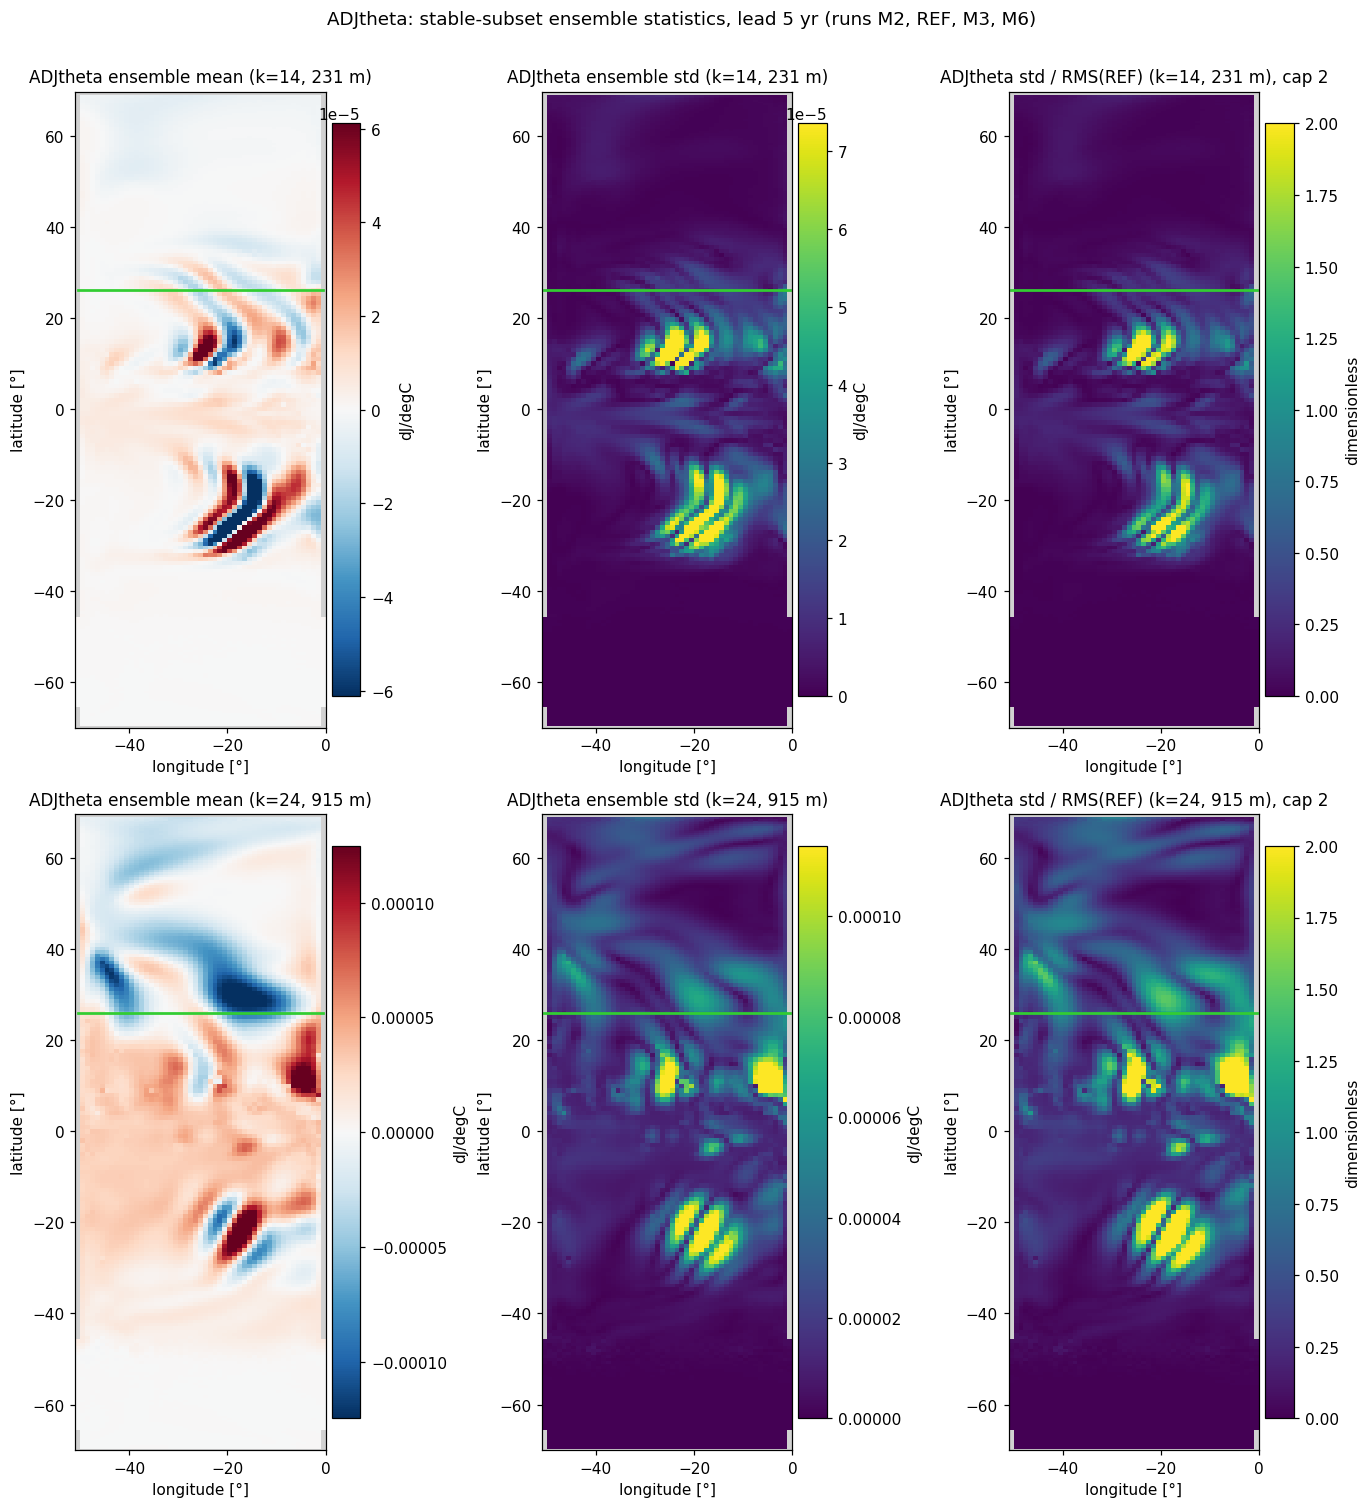

In [3]:
def stat_maps(var, ks, figname):
    """Rows = depths, cols = (mean, std, std/RMS_ref), stable subset."""
    n = len(ks)
    fig, axs = plt.subplots(n, 3, figsize=(12.5, 6.8 * n))
    axs = np.atleast_2d(axs)
    units = ec.ADJ_VARS[var]["units"]
    for r, k in enumerate(ks):
        m = ec.var_mask(var, GRID)[k]
        sel = dict(subset="stable", var=var)
        mean = np.where(m, ds3["mean"].sel(**sel).isel(k=k).values, np.nan)
        std = np.where(m, ds3["std"].sel(**sel).isel(k=k).values, np.nan)
        nsp = np.where(m, ds3["std_over_refrms"].sel(**sel).isel(k=k).values,
                       np.nan)
        ztxt = f"k={k}, {abs(Z[k]):.0f} m"
        ec.plot_map(axs[r, 0], mean, GRID, title=f"{var} ensemble mean ({ztxt})",
                    cbar_label=units)
        ec.plot_map(axs[r, 1], std, GRID, diverging=False, cmap="viridis",
                    vmax=ec.robust_sym(std),
                    title=f"{var} ensemble std ({ztxt})", cbar_label=units)
        ec.plot_map(axs[r, 2], nsp, GRID, diverging=False, cmap="viridis",
                    vmax=2.0, title=f"{var} std / RMS(REF) ({ztxt}), cap 2",
                    cbar_label="dimensionless")
        for ax in axs[r]:
            ec.mark_cost_section(ax, GRID)
    fig.suptitle(f"{var}: stable-subset ensemble statistics, lead 5 yr "
                 f"(runs {', '.join(STABLE)})", y=1.005)
    fig.tight_layout()
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()


stat_maps("ADJtheta", [K_MID, K_DEEP], "ADJtheta_mean_std_nspread_k14_k24")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/ADJdiffkr_mean_std_nspread_k14_k24.png


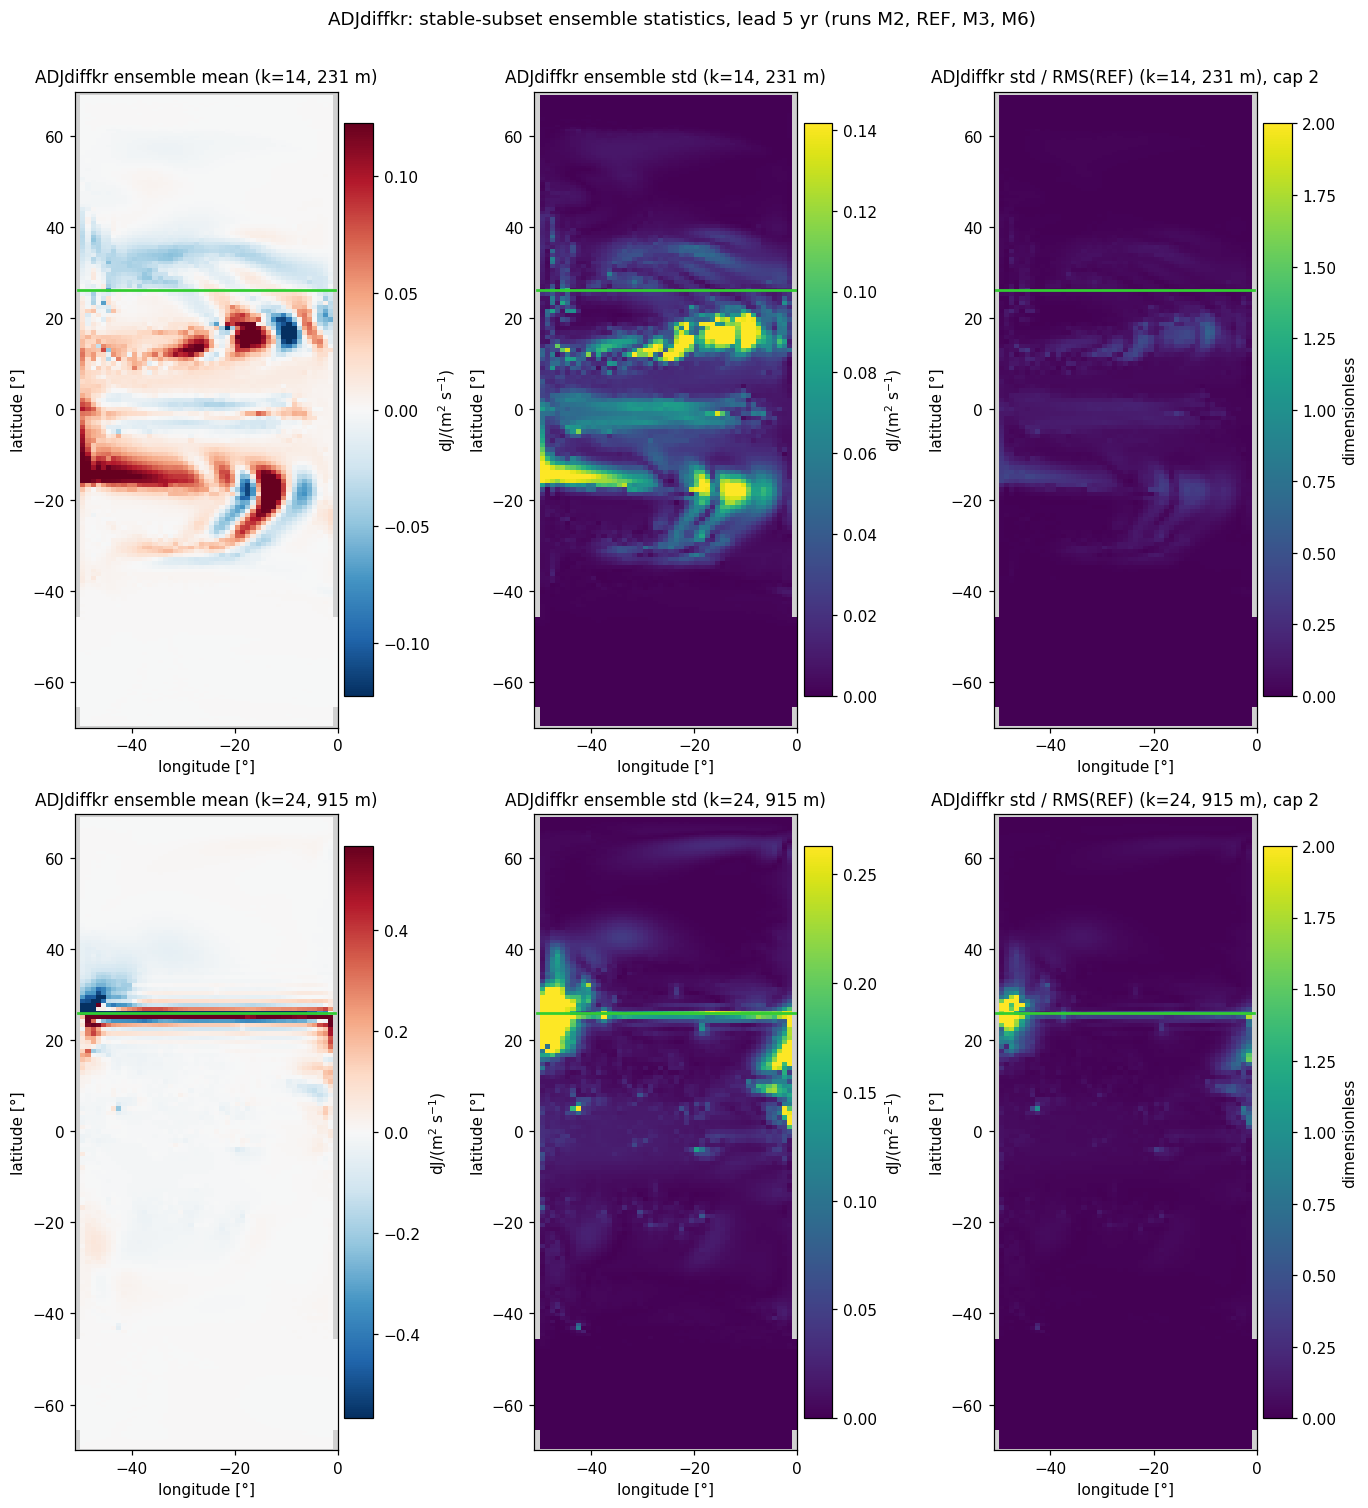

In [4]:
stat_maps("ADJdiffkr", [K_MID, K_DEEP], "ADJdiffkr_mean_std_nspread_k14_k24")

In [5]:
# Where does the spread concentrate?  Fraction of the domain-total std^2 that
# lies within +-5 deg latitude of the cost section, against that band's share
# of the wet cells (a uniform field would put ~the area share there).
band = np.abs(lat - lat[ec.JSEC]) < 5.0

def spread_concentration(var, k):
    m = ec.var_mask(var, GRID)[k]
    sd = ds3["std"].sel(subset="stable", var=var).isel(k=k).values
    tot = np.nansum(np.where(m, sd, 0.0) ** 2)
    inb = np.nansum(np.where(m & band[:, None], sd, 0.0) ** 2)
    wetmean = np.array([np.nanmean(np.where(m[j], sd[j], np.nan))
                        if m[j].any() else np.nan for j in range(len(lat))])
    jmax = int(np.nanargmax(wetmean))
    return inb / tot, m[band].sum() / m.sum(), lat[jmax]

print("share of total std^2 within +-5 deg of the 26.05N cost section")
print("(the band holds ~5.6% of the wet cells):")
for var in ["ADJtheta", "ADJdiffkr"]:
    for k in [K_MID, K_DEEP]:
        fr, share, latmax = spread_concentration(var, k)
        print(f"  {var:10s} k={k:2d} ({abs(Z[k]):4.0f} m): {fr:5.1%} of std^2 "
              f"in band (band wet-cell share {share:.1%}); "
              f"largest zonal-mean std at {latmax:+.1f} deg lat")

share of total std^2 within +-5 deg of the 26.05N cost section
(the band holds ~5.6% of the wet cells):
  ADJtheta   k=14 ( 231 m):  2.5% of std^2 in band (band wet-cell share 5.6%); largest zonal-mean std at +12.9 deg lat
  ADJtheta   k=24 ( 915 m):  8.2% of std^2 in band (band wet-cell share 5.6%); largest zonal-mean std at +10.9 deg lat
  ADJdiffkr  k=14 ( 231 m):  3.5% of std^2 in band (band wet-cell share 5.6%); largest zonal-mean std at -15.8 deg lat
  ADJdiffkr  k=24 ( 915 m): 86.9% of std^2 in band (band wet-cell share 5.6%); largest zonal-mean std at +25.2 deg lat


**Interpretation.** The two variables disagree in *different places*:

- **ADJtheta** spread is *not* section-bound. At k=14 only ~2% of the total
  std² lies within ±5° of the section (below the band's 5.6% wet-cell share),
  and the largest zonal-mean spread sits in the **tropics (~11–13°N)** at both
  depths — the region the sensitivity itself sweeps through on its way
  equatorward/southward (notebook 02's propagation view). The ensemble-mean
  maps keep the familiar reference pattern (strongest signal around and south
  of the section, upstream in the subtropics), and the normalised-spread maps
  show $\tilde{s} < 0.5$ over most of the domain at k=14, growing toward the
  deep tropics at k=24 — spread mostly *scales with* the local signal rather
  than pointing at one hotspot.
- **ADJdiffkr** spread at k=24 is extremely concentrated: **~87% of the total
  std² sits within ±5° of the section** (16× its area share) — the ensemble's
  dJ/dκ fields disagree overwhelmingly *right at the cost section near the
  bottom of the cost integral*, where each member's stratification sets how
  strongly κ mixes heat across the section's isotherms. At k=14 the picture is
  more distributed (largest zonal-mean spread near 16°S).

The capped $\tilde{s}$ panels also make the *agreement* visible: large parts of
the mid-depth interior show spread below ~20% of the reference RMS.

## 3. Vertical structure: is the *relative* spread depth-dependent?

Per level $k$: the wet-cell mean of the ensemble std,
$\langle s\rangle_k$, compared against the reference field's per-level RMS,
$\mathrm{RMS}_k(x_\mathrm{REF})$ — both in the variable's own units — and their
ratio $\langle s\rangle_k / \mathrm{RMS}_k(x_\mathrm{REF})$, a *per-level*
relative spread. Note this deliberately differs from the cached
`std_over_refrms` (which normalises by one global RMS): normalising per level
removes the ~3-decade vertical dynamic range of the fields and answers "at this
depth, how big is the disagreement relative to the signal *at this depth*?".
Levels with fewer than 10 wet cells or zero reference RMS are skipped
(ADJdiffkr is identically zero at k=0, and level 35 has no wet cells).

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/vertical_profiles_std_vs_refRMS.png


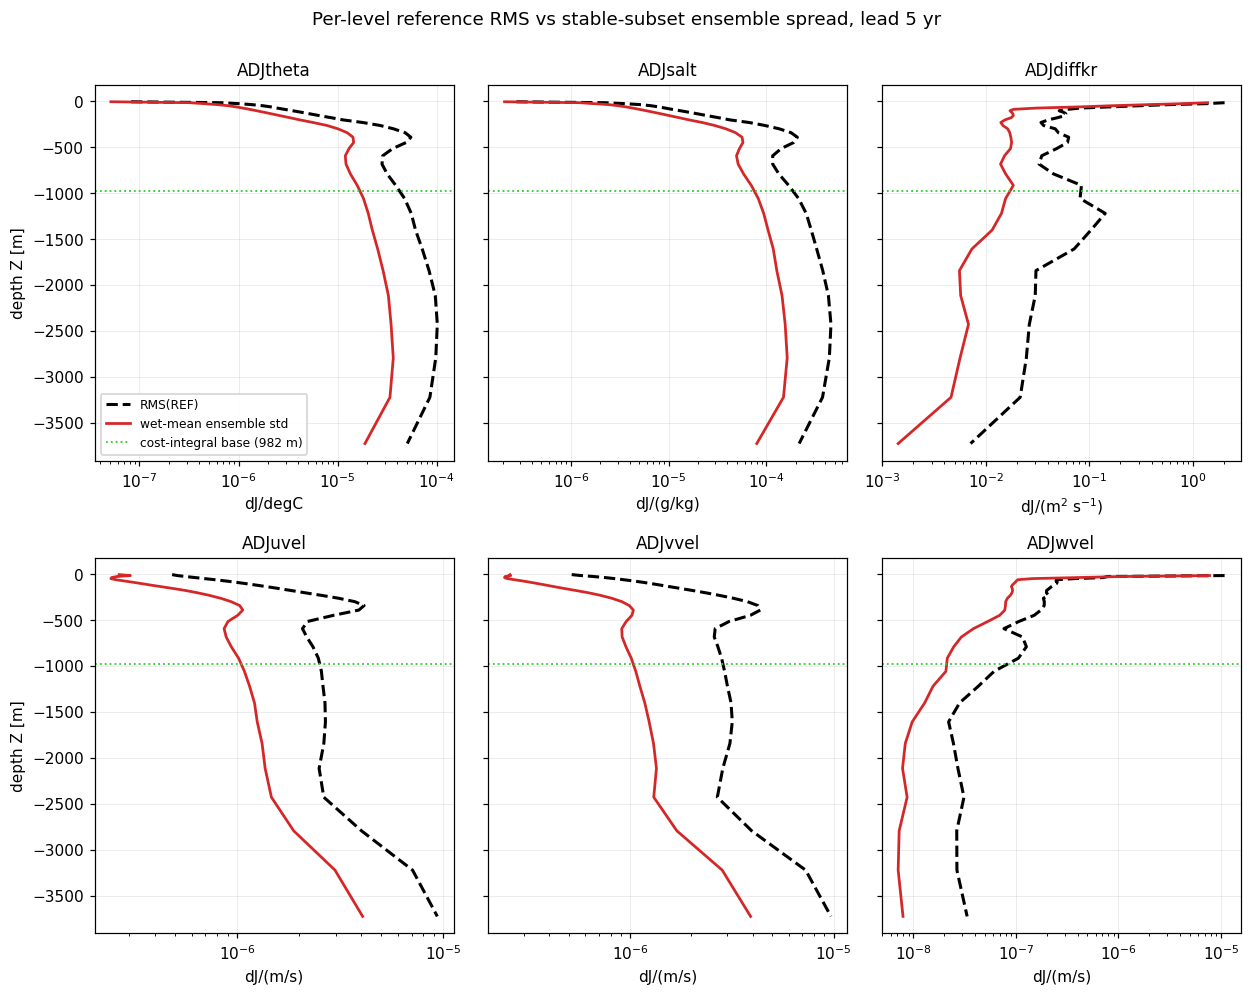

In [6]:
profiles = {}
NK = GRID["hFacC"].shape[0]
for var in ec.ADJ_3D:
    m3 = ec.var_mask(var, GRID)
    sd = ds3["std"].sel(subset="stable", var=var).values
    rf = fin3["field"].sel(run="REF", var=var).values.astype(np.float64)
    refrms = np.full(NK, np.nan)
    stdmean = np.full(NK, np.nan)
    for k in range(NK):
        if m3[k].sum() < 10:
            continue
        refrms[k] = np.sqrt(np.mean(rf[k][m3[k]] ** 2))
        stdmean[k] = np.nanmean(sd[k][m3[k]])
    ratio = np.where(refrms > 0, stdmean / refrms, np.nan)
    profiles[var] = (refrms, stdmean, ratio)

fig, axs = plt.subplots(2, 3, figsize=(11.5, 9), sharey=True)
for ax, var in zip(axs.ravel(), ec.ADJ_3D):
    refrms, stdmean, _ = profiles[var]
    pos = lambda a: np.where(a > 0, a, np.nan)   # log axis: drop exact zeros
    ax.plot(pos(refrms), Z, color="black", lw=2.0, ls="--", label="RMS(REF)")
    ax.plot(pos(stdmean), Z, color="tab:red", lw=1.8,
            label="wet-mean ensemble std")
    ax.axhline(-982.4, color="limegreen", lw=1.2, ls=":",
               label="cost-integral base (982 m)")
    ax.set_xscale("log")
    ax.set_title(var)
    ax.set_xlabel(ec.ADJ_VARS[var]["units"])
axs[0, 0].set_ylabel("depth Z [m]")
axs[1, 0].set_ylabel("depth Z [m]")
axs[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("Per-level reference RMS vs stable-subset ensemble spread, "
             "lead 5 yr", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "vertical_profiles_std_vs_refRMS")
plt.show()

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/vertical_profiles_relative_spread.png


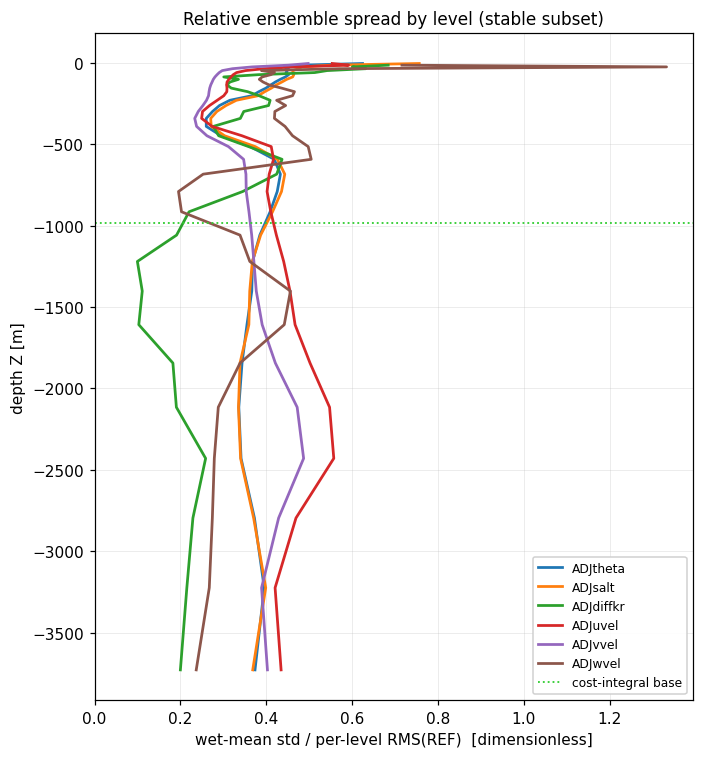

per-level relative spread at selected depths (k=2: 26 m, k=14: 231 m, k=24: 915 m, k=28: 1608 m):
      var  ratio_k2  ratio_k14  ratio_k24  ratio_k28  ratio_median
 ADJtheta     0.442      0.315      0.409      0.355         0.385
  ADJsalt     0.483      0.330      0.414      0.359         0.396
ADJdiffkr     0.600      0.409      0.220      0.103         0.327
  ADJuvel     0.463      0.286      0.410      0.467         0.402
  ADJvvel     0.367      0.261      0.360      0.390         0.321
  ADJwvel     1.332      0.424      0.203      0.442         0.415


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 7))
for var in ec.ADJ_3D:
    ratio = profiles[var][2]
    ax.plot(ratio, Z, lw=1.8, label=var)
ax.axhline(-982.4, color="limegreen", lw=1.2, ls=":",
           label="cost-integral base")
ax.set_xlabel("wet-mean std / per-level RMS(REF)  [dimensionless]")
ax.set_ylabel("depth Z [m]")
ax.set_title("Relative ensemble spread by level (stable subset)")
ax.set_xlim(0, None)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "vertical_profiles_relative_spread")
plt.show()

rows = []
for var in ec.ADJ_3D:
    refrms, stdmean, ratio = profiles[var]
    rows.append(dict(var=var,
                     ratio_k2=ratio[2], ratio_k14=ratio[K_MID],
                     ratio_k24=ratio[K_DEEP], ratio_k28=ratio[28],
                     ratio_median=np.nanmedian(ratio)))
prof_tbl = pd.DataFrame(rows)
print("per-level relative spread at selected depths "
      f"(k=2: {abs(Z[2]):.0f} m, k=14: {abs(Z[14]):.0f} m, "
      f"k=24: {abs(Z[24]):.0f} m, k=28: {abs(Z[28]):.0f} m):")
print(prof_tbl.to_string(index=False, float_format="{:.3f}".format))

**Interpretation.** The absolute profiles (dashed black vs red) track each other
within a factor 2–3 at every depth for all six variables — the ensemble spread
largely **scales with the local signal amplitude**, which itself spans ~3
decades from surface to abyss. The ratio panel makes the residual depth
dependence explicit:

- **ADJtheta / ADJsalt**: relative spread ~0.3–0.6 throughout the column, with
  its *maximum near the surface* (~0.6 at 5–25 m) and a broad minimum around
  200–250 m. There is no depth where the temperature sensitivity is
  κ-independent; equally, no depth where the stable ensemble loses the signal.
- **ADJdiffkr**: relative spread is largest in the near-surface levels (~0.6 at
  26 m) and *smallest below the cost-integral base* (~0.10 at 1600 m) — the deep
  dJ/dκ pattern is the most κ-robust part of that field in relative terms, even
  though section 2 showed its largest absolute disagreement sits at the section
  near 900 m (large signal, large spread).
- The velocity/wvel sensitivities behave like theta/salt (ratios ~0.2–0.5).

So: relative spread is only mildly depth-dependent — a factor ~2–6 across the
column depending on the variable — against the ~1000× depth variation of the
fields themselves. The cost-depth range (k ≤ 24) is *not* systematically more
robust than the levels below it; if anything ADJdiffkr is more κ-robust below.

## 4. Where does the ensemble *agree*? Signal-robustness maps

The robustness measure is $|\overline{x}_c| / s_c$ — how many ensemble standard
deviations the ensemble-mean sensitivity sits away from zero. With n = 4 this
is a demanding yardstick (a single member disagreeing in sign is usually enough
to push it below 2), so cells with $|\overline{x}| > 2s$ are cells where all
four stable runs put essentially the *same* sensitivity.

Alongside the two ADJtheta depth maps, an **adxx-style view of dJ/dκ**: each
run's final ADJdiffkr summed over the column,
$G(j,i) = \sum_k \mathrm{ADJdiffkr}(k,j,i)$ — the gradient of J with respect
to a *column-uniform* κ change at that point, i.e. exactly the map a κ-input
surrogate would have to predict. (Recall from notebook 01 that adxx_diffkr
equals the final ADJdiffkr dump in every run, corr 1.000000, so this is
equivalently the vertical sum of the control gradient.) Its ensemble mean and
$|\overline{G}|/s_G$ are mapped, and the per-run domain totals
$\sum_{j,i} G$ = dJ/d(uniform κ) are tabulated.

domain totals sum_ji G = dJ/d(uniform kappa)  [dJ per (m^2/s)]:
  M2   (x0.5):    -251.3
  REF  (x1):    -435.6
  M3   (x2):     -77.9
  M6   (x16):    +673.3


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/robustness_maps.png


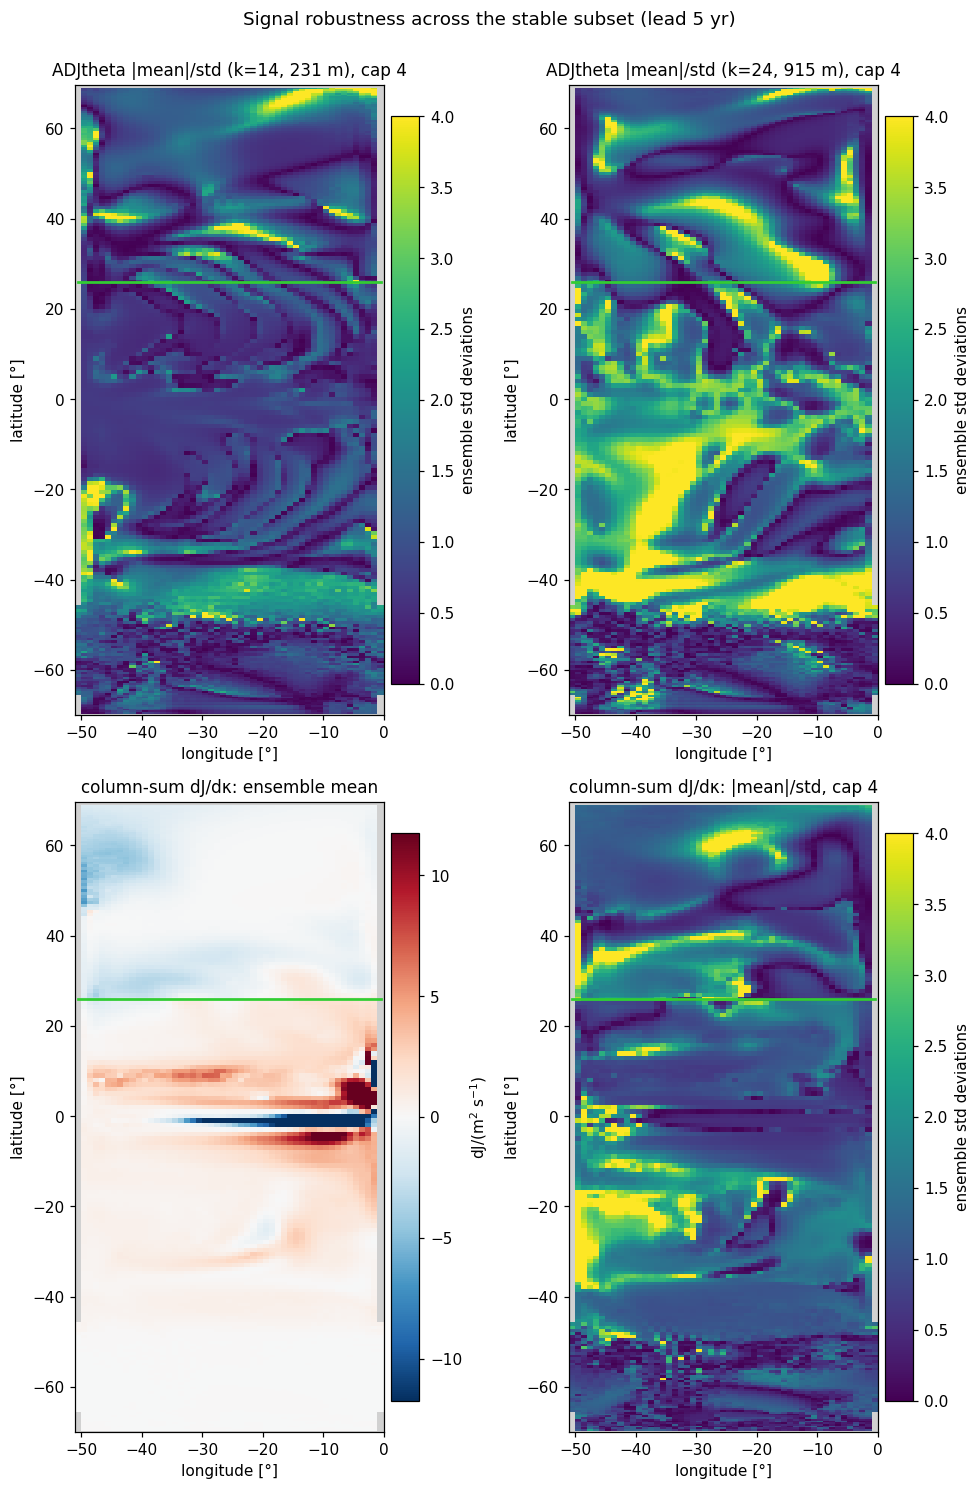

ADJtheta k=14: 10.4% of wet cells with |mean|>2std  (within +-5deg of section: 2.0%, elsewhere: 10.9%)
ADJtheta k=24: 28.0% of wet cells with |mean|>2std  (within +-5deg of section: 20.4%, elsewhere: 28.5%)
column-sum dJ/dkappa: |mean|>2std in 13.5% of wet columns (all 4 runs same sign in 66.8%);
  dropping M6 (['M2', 'REF', 'M3']): |mean|>2std in 32.0%, same sign in 75.8%


In [8]:
# --- vertically-summed dJ/dkappa per stable run --------------------------
mC = ec.var_mask("ADJdiffkr", GRID)
wet2 = mC.any(axis=0)
vsum = {}
for run in STABLE:
    fld = fin3["field"].sel(run=run, var="ADJdiffkr").values.astype(np.float64)
    vsum[run] = np.where(mC, fld, 0.0).sum(axis=0)
vstack = np.stack([vsum[r] for r in STABLE])
vs_mean = vstack.mean(axis=0)
vs_std = vstack.std(axis=0, ddof=1)
vs_rob = np.where(vs_std > 0, np.abs(vs_mean) / vs_std, np.nan)

print("domain totals sum_ji G = dJ/d(uniform kappa)  [dJ per (m^2/s)]:")
for run in STABLE:
    print(f"  {run:4s} (x{ec.RUNS[run]['factor']:g}): {vsum[run][wet2].sum():+9.1f}")

# robustness maps ---------------------------------------------------------
def robmap(var, k):
    m = ec.var_mask(var, GRID)[k]
    mn = ds3["mean"].sel(subset="stable", var=var).isel(k=k).values
    sd = ds3["std"].sel(subset="stable", var=var).isel(k=k).values
    rob = np.where(sd > 0, np.abs(mn) / sd, np.nan)
    return np.where(m, rob, np.nan), m

fig, axs = plt.subplots(2, 2, figsize=(9.0, 13.5))
for ax, k in zip(axs[0], [K_MID, K_DEEP]):
    rob, m = robmap("ADJtheta", k)
    ec.plot_map(ax, rob, GRID, diverging=False, cmap="viridis", vmax=4.0,
                title=f"ADJtheta |mean|/std (k={k}, {abs(Z[k]):.0f} m), cap 4",
                cbar_label="ensemble std deviations")
    ec.mark_cost_section(ax, GRID)
ec.plot_map(axs[1, 0], np.where(wet2, vs_mean, np.nan), GRID,
            title="column-sum dJ/d\u03ba: ensemble mean",
            cbar_label="dJ/(m$^2$ s$^{-1}$)")
ec.mark_cost_section(axs[1, 0], GRID)
ec.plot_map(axs[1, 1], np.where(wet2, vs_rob, np.nan), GRID, diverging=False,
            cmap="viridis", vmax=4.0,
            title="column-sum dJ/d\u03ba: |mean|/std, cap 4",
            cbar_label="ensemble std deviations")
ec.mark_cost_section(axs[1, 1], GRID)
fig.suptitle("Signal robustness across the stable subset (lead 5 yr)", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "robustness_maps")
plt.show()

# quantify, incl. the role of M6 -----------------------------------------
for k in [K_MID, K_DEEP]:
    rob, m = robmap("ADJtheta", k)
    ok = (rob > 2) & m
    print(f"ADJtheta k={k}: {ok.sum() / m.sum():.1%} of wet cells with "
          f"|mean|>2std  (within +-5deg of section: "
          f"{ok[band].sum() / max(m[band].sum(), 1):.1%}, elsewhere: "
          f"{ok[~band].sum() / max(m[~band].sum(), 1):.1%})")
frac4 = np.mean((vs_rob > 2)[wet2])
sign4 = np.mean((np.sign(vstack) == np.sign(vsum["REF"])).all(0)[wet2])
no_m6 = [r for r in STABLE if r != "M6"]
v3 = np.stack([vsum[r] for r in no_m6])
rob3 = np.where(v3.std(0, ddof=1) > 0,
                np.abs(v3.mean(0)) / v3.std(0, ddof=1), np.nan)
sign3 = np.mean((np.sign(v3) == np.sign(vsum["REF"])).all(0)[wet2])
print(f"column-sum dJ/dkappa: |mean|>2std in {frac4:.1%} of wet columns "
      f"(all 4 runs same sign in {sign4:.1%});")
print(f"  dropping M6 ({no_m6}): |mean|>2std in "
      f"{np.mean((rob3 > 2)[wet2]):.1%}, same sign in {sign3:.1%}")

### Fraction of wet cells with $|\overline{x}| > 2s$, per variable

      var ndim  frac_agree_2sigma
 ADJtheta  3-D              0.158
  ADJsalt  3-D              0.155
ADJdiffkr  3-D              0.117
  ADJuvel  3-D              0.116
  ADJvvel  3-D              0.085
  ADJwvel  3-D              0.079
  ADJtaux  2-D              0.062
  ADJtauy  2-D              0.216
  ADJqnet  2-D              0.121
   ADJqsw  2-D              0.021
 ADJempmr  2-D              0.165


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/agreement_fraction_bars.png


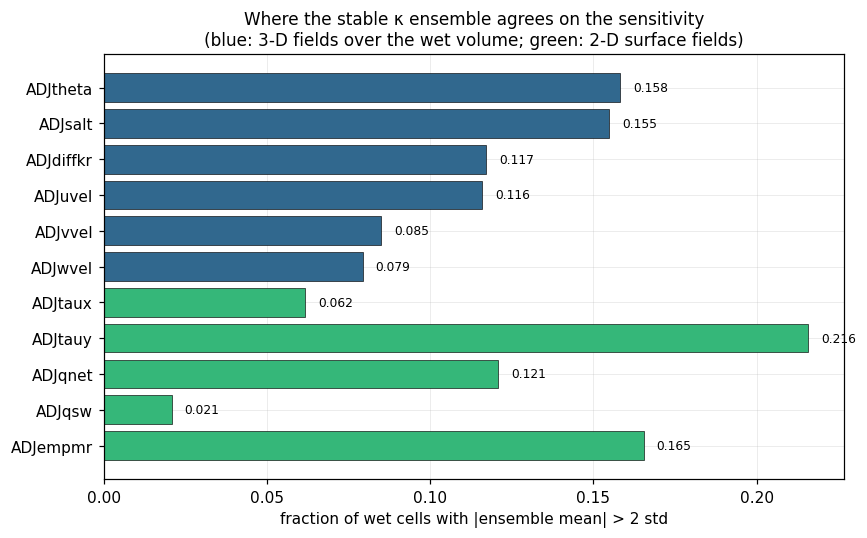

In [9]:
agree_rows = []
for var in list(ec.ADJ_3D) + list(ec.ADJ_2D):
    dsx = ds3 if var in ec.ADJ_3D else ds2
    m = ec.var_mask(var, GRID)
    mn = dsx["mean"].sel(subset="stable", var=var).values
    sd = dsx["std"].sel(subset="stable", var=var).values
    ok = np.abs(mn) > 2.0 * sd
    agree_rows.append(dict(var=var, ndim="3-D" if var in ec.ADJ_3D else "2-D",
                           frac_agree_2sigma=float(np.mean(ok[m]))))
agree = pd.DataFrame(agree_rows)
print(agree.to_string(index=False, float_format="{:.3f}".format))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#31688e" if nd == "3-D" else "#35b779" for nd in agree["ndim"]]
bars = ax.barh(np.arange(len(agree))[::-1], agree["frac_agree_2sigma"],
               color=colors, edgecolor="black", lw=0.4)
ax.set_yticks(np.arange(len(agree))[::-1])
ax.set_yticklabels(agree["var"])
for y, v in zip(np.arange(len(agree))[::-1], agree["frac_agree_2sigma"]):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("fraction of wet cells with |ensemble mean| > 2 std")
ax.set_title("Where the stable \u03ba ensemble agrees on the sensitivity\n"
             "(blue: 3-D fields over the wet volume; green: 2-D surface fields)")
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "agreement_fraction_bars")
plt.show()

**Interpretation.** Only **2–29% of wet cells** clear the 2σ agreement bar,
depending on the variable (ADJtauy 22% and the initial-state sensitivities
ADJtheta/ADJsalt ~16% at the top; ADJqsw 2% at the bottom) — with n = 4 and one
degraded member this is a floor estimate, but it makes the central point: **the
κ ensemble agrees on the sensitivity only over a minority of the domain**.

Depth matters for ADJtheta: robustness *rises* toward the cost depth (11% of
cells at 231 m → 29% at 915 m), and at k=24 the near-section band is itself
substantially robust (20%). At k=14 the robust cells sit almost entirely
*away* from the section (2% in the band vs 12% outside): near the section at
mid-depth the members agree that sensitivity is large but not on its
fine-grained sign pattern, while the broad far-field structure survives κ
changes.

The **column-summed dJ/dκ** view is the sobering one for the surrogate: its
ensemble mean keeps the reference's coherent negative-at-the-section structure,
but only **13.5% of wet columns** pass 2σ and only 67% keep one sign across the
four runs. Dropping M6 raises those to 32% and 76% — i.e. a large share of the
apparent dJ/dκ disagreement is *M6's structural degradation*, not smooth κ
dependence; but even the M2–REF–M3 trio (a factor 4 in κ) leaves two thirds of
the columns below 2σ. The per-run domain totals quantify why: dJ/d(uniform κ)
swings from −251 (M2) to −436 (REF) to −78 (M3) and *flips sign* to +673 for
M6 — the global gradient is strongly non-monotonic in κ and unusable at 16×
(consistent with notebook 01's failed linear ΔJ prediction).

## 5. Surface (2-D) sensitivities, and which variables are most κ-sensitive

Same three-panel treatment for the two leading surface-forcing sensitivities,
**ADJtaux** (zonal wind stress) and **ADJqnet** (net heat flux). Then the
cross-variable ranking: for each of the 11 variables the domain-integrated
spread, normalised by the reference amplitude so that different units become
comparable — **only normalised spread is comparable across variables** (raw
adxx/ADJ magnitudes differ by ~5 orders between variable classes; units
caveat as in the master plan). Two summary measures, deliberately different in
their tail sensitivity:

$$S_\mathrm{RMS} = \frac{\mathrm{RMS}_\mathrm{wet}(s)}{\mathrm{RMS}_\mathrm{wet}(x_\mathrm{REF})}
\qquad\text{(dominated by the few highest-spread cells)},$$
$$S_\mathrm{mean} = \frac{\langle s\rangle_\mathrm{wet}}{\mathrm{RMS}_\mathrm{wet}(x_\mathrm{REF})}
\qquad\text{(the typical wet cell)}.$$

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/ADJtaux_mean_std_nspread.png


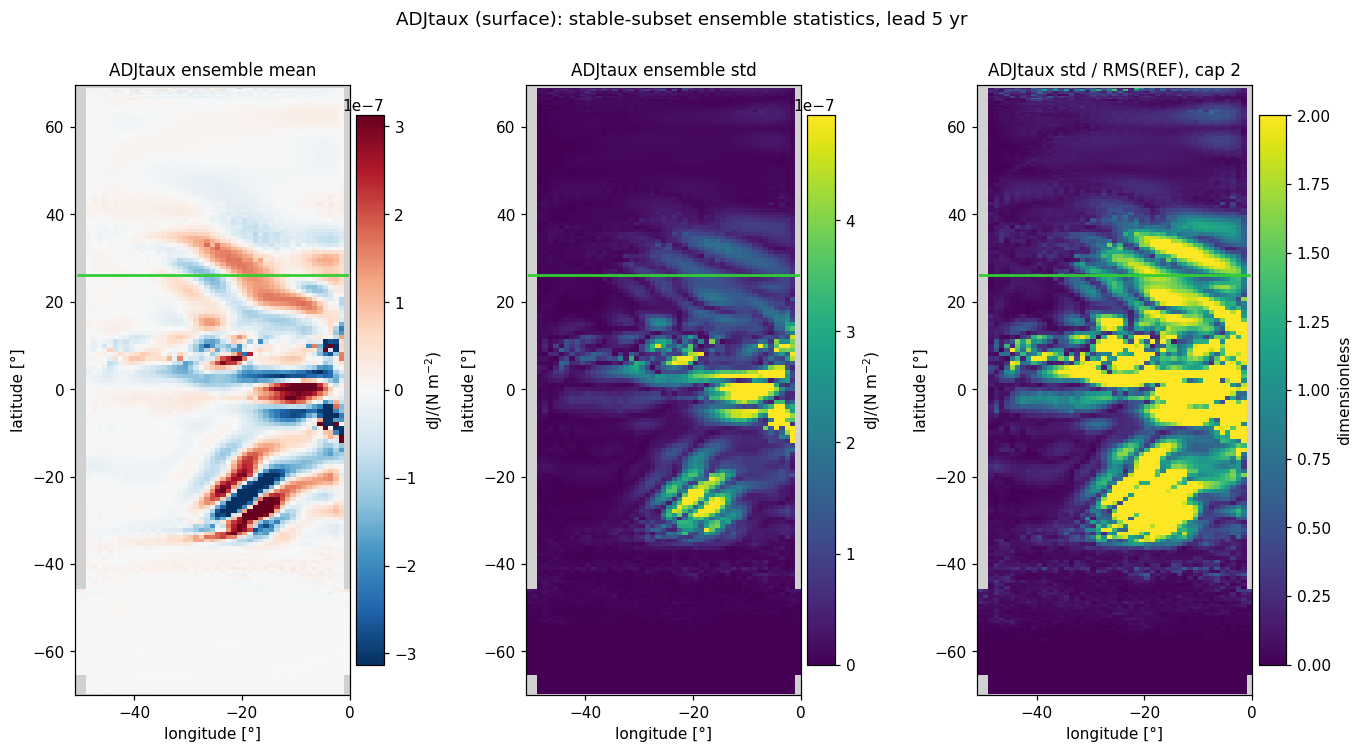

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/ADJqnet_mean_std_nspread.png


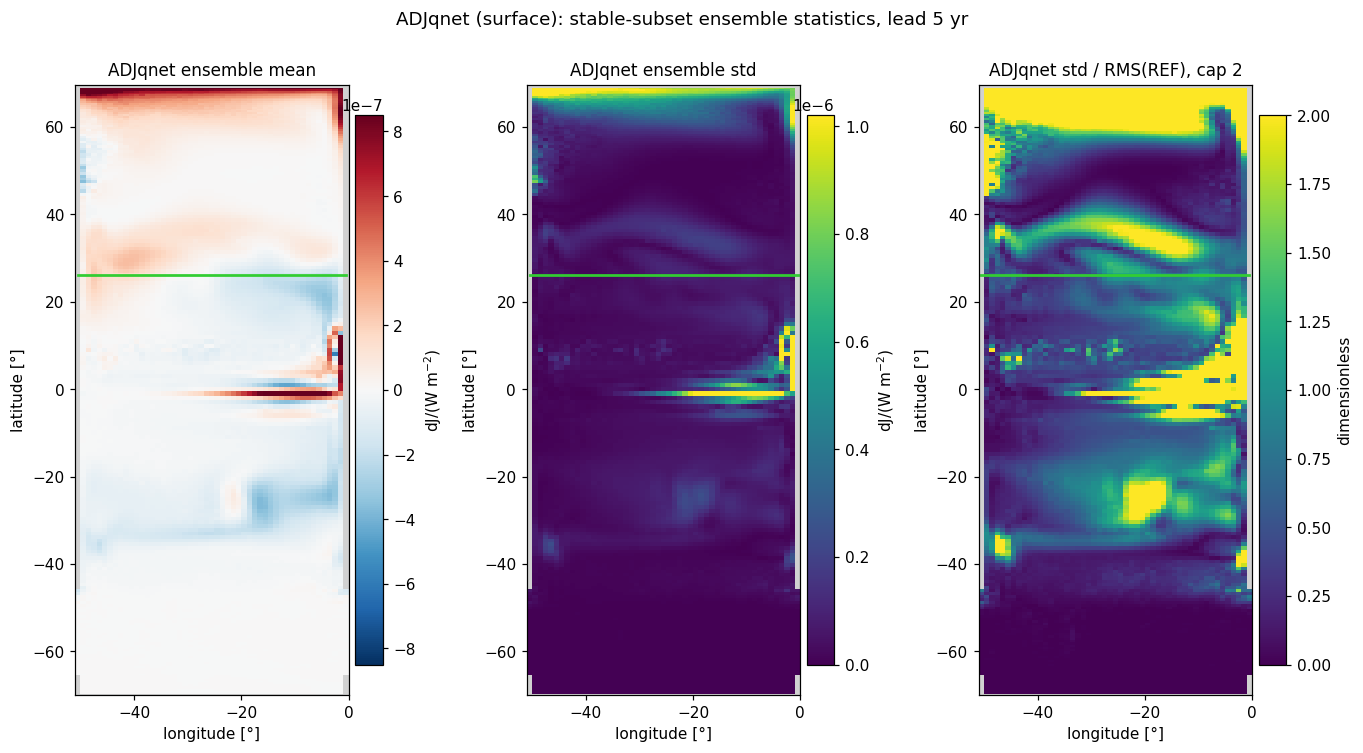

In [10]:
def stat_maps_2d(var, figname):
    m = ec.var_mask(var, GRID)
    sel = dict(subset="stable", var=var)
    units = ec.ADJ_VARS[var]["units"]
    mean = np.where(m, ds2["mean"].sel(**sel).values, np.nan)
    std = np.where(m, ds2["std"].sel(**sel).values, np.nan)
    nsp = np.where(m, ds2["std_over_refrms"].sel(**sel).values, np.nan)
    fig, axs = plt.subplots(1, 3, figsize=(12.5, 6.8))
    ec.plot_map(axs[0], mean, GRID, title=f"{var} ensemble mean",
                cbar_label=units)
    ec.plot_map(axs[1], std, GRID, diverging=False, cmap="viridis",
                vmax=ec.robust_sym(std), title=f"{var} ensemble std",
                cbar_label=units)
    ec.plot_map(axs[2], nsp, GRID, diverging=False, cmap="viridis", vmax=2.0,
                title=f"{var} std / RMS(REF), cap 2",
                cbar_label="dimensionless")
    for ax in axs:
        ec.mark_cost_section(ax, GRID)
    fig.suptitle(f"{var} (surface): stable-subset ensemble statistics, "
                 "lead 5 yr", y=1.0)
    fig.tight_layout()
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()


stat_maps_2d("ADJtaux", "ADJtaux_mean_std_nspread")
stat_maps_2d("ADJqnet", "ADJqnet_mean_std_nspread")

written /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/05_ensemble_spread_summary.csv

      var ndim ref_rms_wet nspread_rms nspread_mean frac_agree_2sigma
 ADJtheta  3-D   4.628e-05       0.656        0.258             0.158
  ADJsalt  3-D   2.025e-04       0.647        0.255             0.155
ADJdiffkr  3-D   4.301e-01       4.140        0.214             0.117
  ADJuvel  3-D   2.879e-06       0.776        0.316             0.116
  ADJvvel  3-D   3.139e-06       0.817        0.283             0.085
  ADJwvel  3-D   1.868e-06       2.558        0.170             0.079
  ADJtaux  2-D   7.570e-08       1.655        0.585             0.062
  ADJtauy  2-D   3.761e-03       2.516        0.526             0.216
  ADJqnet  2-D   8.111e-08       2.957        1.246             0.121
   ADJqsw  2-D   8.029e-12       0.868        0.436             0.021
 ADJempmr  2-D   5.241e-02       2.693        1.123             0.165

per-run wet RMS of final ADJdiffkr (amplitude

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/normalized_spread_by_var.png


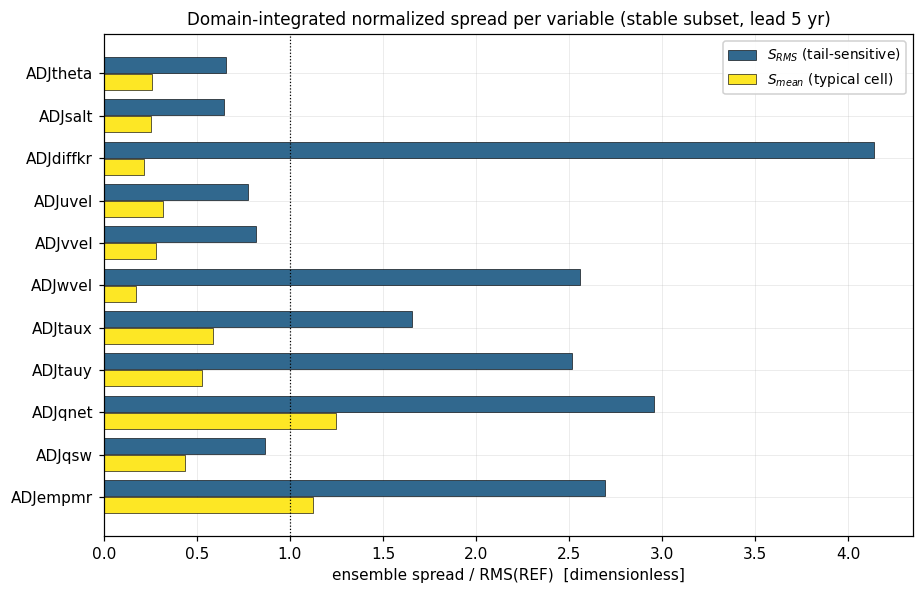

In [11]:
# Cross-variable normalized spread + the agreement fraction, as one table.
spread_rows = []
for var in list(ec.ADJ_3D) + list(ec.ADJ_2D):
    is3d = var in ec.ADJ_3D
    dsx, finx = (ds3, fin3) if is3d else (ds2, fin2)
    m = ec.var_mask(var, GRID)
    sd = dsx["std"].sel(subset="stable", var=var).values
    rf = finx["field"].sel(run="REF", var=var).values.astype(np.float64)
    ref_rms = np.sqrt(np.mean(rf[m] ** 2))
    spread_rows.append(dict(
        var=var, ndim="3-D" if is3d else "2-D", ref_rms_wet=ref_rms,
        nspread_rms=float(np.sqrt(np.nanmean(sd[m] ** 2)) / ref_rms),
        nspread_mean=float(np.nanmean(sd[m]) / ref_rms)))
spread = pd.DataFrame(spread_rows).merge(agree[["var", "frac_agree_2sigma"]],
                                         on="var")
ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)
csv_path = ec.STATS_ROOT / "ensemble_spread_summary.csv"
spread.to_csv(csv_path, index=False)
print(f"written {csv_path}\n")
print(spread.to_string(index=False,
                       formatters={"ref_rms_wet": "{:.3e}".format,
                                   "nspread_rms": "{:.3f}".format,
                                   "nspread_mean": "{:.3f}".format,
                                   "frac_agree_2sigma": "{:.3f}".format}))

# why ADJdiffkr tops the RMS measure: its AMPLITUDE scales strongly with kappa
print("\nper-run wet RMS of final ADJdiffkr (amplitude vs kappa):")
for run in STABLE:
    fld = fin3["field"].sel(run=run, var="ADJdiffkr").values.astype(np.float64)
    r = np.sqrt(np.mean(fld[mC] ** 2))
    print(f"  {run:4s} (x{ec.RUNS[run]['factor']:g}): {r:9.4f}   "
          f"({r / 0.4301 if run != 'REF' else 1.0:6.2f} x REF)"
          if run != "REF" else
          f"  {run:4s} (x{ec.RUNS[run]['factor']:g}): {r:9.4f}   (  1.00 x REF)")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
y = np.arange(len(spread))[::-1]
ax.barh(y + 0.2, spread["nspread_rms"], height=0.38, color="#31688e",
        edgecolor="black", lw=0.4, label="$S_{RMS}$ (tail-sensitive)")
ax.barh(y - 0.2, spread["nspread_mean"], height=0.38, color="#fde725",
        edgecolor="black", lw=0.4, label="$S_{mean}$ (typical cell)")
ax.set_yticks(y)
ax.set_yticklabels(spread["var"])
ax.axvline(1.0, color="black", lw=0.8, ls=":")
ax.set_xlabel("ensemble spread / RMS(REF)  [dimensionless]")
ax.set_title("Domain-integrated normalized spread per variable "
             "(stable subset, lead 5 yr)")
ax.legend()
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "normalized_spread_by_var")
plt.show()

**Interpretation.**

- **Surface maps**: ADJtaux disagreement concentrates in the **equatorial band**
  (largest std near 3°N) and along the subtropical gyre margins; ADJqnet spread
  is largest at **high northern latitudes (~69°N)** — the deep-water-formation
  region whose surface heat loss feeds the section transport, where the mean
  sensitivity is also strong. Neither is section-bound: for both fields well
  under 5% of the std² lies within ±5° of 26°N (section-2 style computation not
  repeated here; visible directly in the maps).
- **The two spread measures disagree instructively.** On the typical-cell
  measure $S_\mathrm{mean}$, the heat/freshwater-flux sensitivities are the
  most κ-sensitive variables (ADJqnet 1.25, ADJempmr 1.12 — spread *larger than
  the reference signal* at the typical cell), the wind stresses come next
  (~0.5–0.6), and all six 3-D fields sit at 0.17–0.32. On the tail-sensitive
  $S_\mathrm{RMS}$, **ADJdiffkr jumps from 11th to 1st (4.14)**: its spread is
  concentrated in a few near-section cells (section 2) whose amplitude differs
  enormously between runs. The per-run RMS table shows why — the *amplitude* of
  dJ/dκ falls monotonically and steeply with background κ (M2 at 0.5×: 8.4×
  REF; M3 at 2×: 0.21×; M6 at 16×: 0.11× — a ~77× range, roughly
  κ^(−1.3...−2.5) per octave near 1×), which is itself a leading result for the
  surrogate: the *input-gradient magnitude* of the map κ → J is a strong
  function of κ.
- **Ranking verdict**: by typical-cell spread the κ ensemble scrambles the
  *surface flux* sensitivities most and the 3-D state sensitivities least; by
  tail spread the *diffusivity* sensitivity is the most κ-dependent field of
  all. Both statements matter for choosing surrogate targets.

## 6. Per-member view: (member − REF) / RMS(REF) for ADJtheta at 231 m

The ensemble std mixes all members; these maps show *who* differs *where*:
each stable member's final ADJtheta minus the reference at k=14, normalised by
the reference's global wet RMS (4.63×10⁻⁵ dJ/°C) and clipped at ±2, i.e. the
per-member map behind notebook 04's aggregate metrics (quoted per panel).

RMS_wet(REF ADJtheta) = 4.628e-05 dJ/degC (normalisation)
M2: corr 0.794, amp ratio 1.365, median |diff|/RMS(REF) at k=14: 0.0165
M3: corr 0.829, amp ratio 0.770, median |diff|/RMS(REF) at k=14: 0.0119
M6: corr 0.435, amp ratio 0.569, median |diff|/RMS(REF) at k=14: 0.0206


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/reldiff_maps_ADJtheta_k14.png


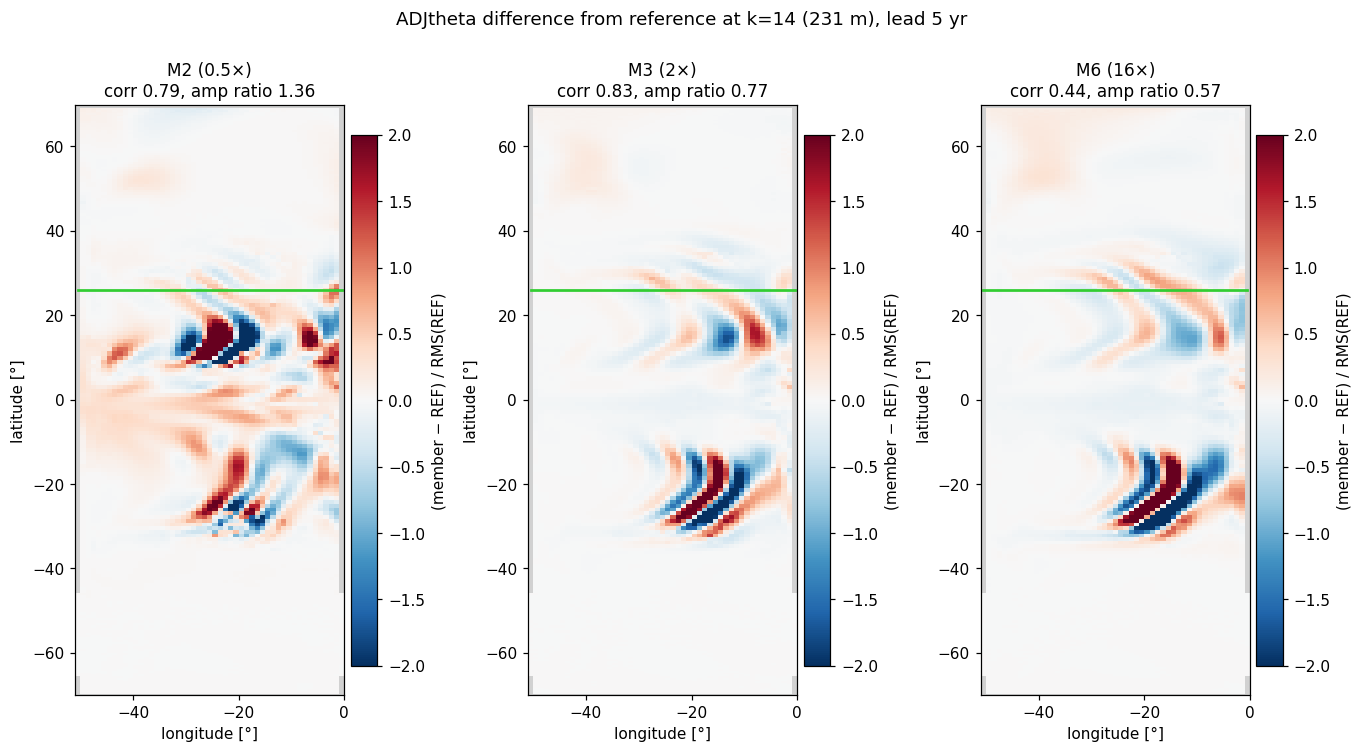

In [12]:
mth = ec.var_mask("ADJtheta", GRID)
rf_th = fin3["field"].sel(run="REF", var="ADJtheta").values.astype(np.float64)
rms_ref_glob = np.sqrt(np.mean(rf_th[mth] ** 2))
print(f"RMS_wet(REF ADJtheta) = {rms_ref_glob:.4g} dJ/degC (normalisation)")

mmt = ec.open_cache("member_metrics_time.nc")
assert int(mmt.time[0]) == ec.NITER0          # time index 0 = lead 5 yr
fin_met = mmt.sel(weighting="none").isel(time=0)

fig, axs = plt.subplots(1, 3, figsize=(12.5, 6.8))
for ax, run in zip(axs, ["M2", "M3", "M6"]):
    diff = (fin3["field"].sel(run=run, var="ADJtheta").values[K_MID]
            - rf_th[K_MID]) / rms_ref_glob
    diff = np.where(mth[K_MID], diff, np.nan)
    c = float(fin_met["corr"].sel(member=run, var="ADJtheta"))
    a = float(fin_met["amp_ratio"].sel(member=run, var="ADJtheta"))
    ec.plot_map(ax, diff, GRID, vmax=2.0,
                title=f"{ec.RUNS[run]['label']}\ncorr {c:.2f}, "
                      f"amp ratio {a:.2f}",
                cbar_label="(member \u2212 REF) / RMS(REF)")
    ec.mark_cost_section(ax, GRID)
    print(f"{run}: corr {c:.3f}, amp ratio {a:.3f}, "
          f"median |diff|/RMS(REF) at k={K_MID}: "
          f"{np.nanmedian(np.abs(diff)):.4f}")
fig.suptitle(f"ADJtheta difference from reference at k={K_MID} "
             f"({abs(Z[K_MID]):.0f} m), lead 5 yr", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "reldiff_maps_ADJtheta_k14")
plt.show()

**Interpretation.** The maps match notebook 04's aggregate numbers
(unweighted, final snapshot): M2 corr 0.79 with amplitude ratio 1.37, M3 corr
0.83 with 0.77, M6 corr 0.44 with 0.57. M2 and M3 differ from REF in a
**κ-antisymmetric** way — where M2 (0.5×) is redder, M3 (2×) tends blue — and
their differences are moderate at the typical cell (median |diff| ≈ 1–2% of the
reference RMS) while reaching O(1) in the tropical band and near the section.
M6's map is qualitatively different: broad same-sign patches replaced by
speckle, the signature of its structural degradation rather than a smooth κ
response. This is the per-member picture behind section 4's finding that
dropping M6 halves the apparent disagreement.

## 7. Honesty panel: what the all-8 statistics look like

One map, shown once: the ensemble std of ADJtheta at k=14 over **all eight
runs**. The blown members (M1, M5, M7 with final RMS 10⁴–10¹¹, M4 with
inf/NaN) dominate every cell, so the std is astronomically large everywhere —
and over most of the domain it is not even representable: squaring M4's
~10³⁷–10³⁸ values overflows float32, so the cached std is **inf** there
(plotted at the top of the colour scale). This is why every physical statement
in this notebook uses the stable subset.

all8 std, ADJtheta k=14: finite in 28.4% of 9627 wet cells (6893 cells non-finite = float32 overflow)
finite values span 2.72e+05 .. 3.92e+09
stable-subset median std at the same level: 1.15e-06
=> even the SMALLEST all8 std exceeds the stable median by a factor 2.4e+11


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/05_ensemble_statistics/all8_std_honesty_panel.png


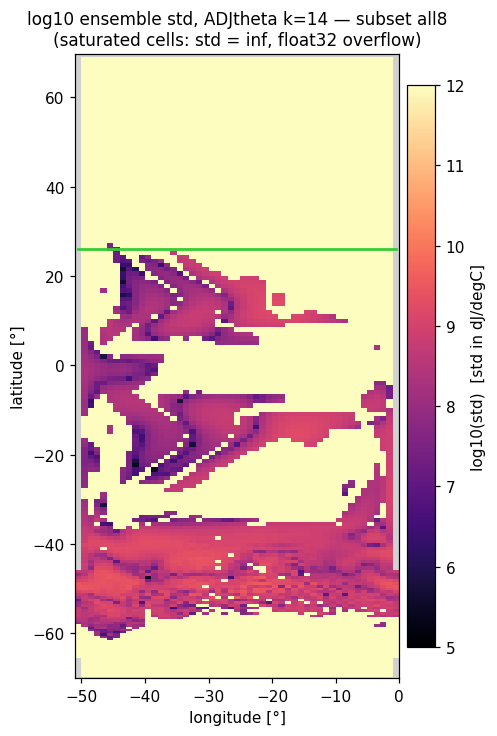

In [13]:
s8 = ds3["std"].sel(subset="all8", var="ADJtheta").isel(k=K_MID).values
m14 = mth[K_MID]
finite = np.isfinite(s8) & m14
n_wet = int(m14.sum())
n_inf = int((m14 & ~np.isfinite(s8)).sum())
smin, smax = s8[finite].min(), s8[finite].max()
stable_med = float(np.nanmedian(
    ds3["std"].sel(subset="stable", var="ADJtheta").isel(k=K_MID).values[m14]))
print(f"all8 std, ADJtheta k={K_MID}: finite in {finite.sum() / n_wet:.1%} "
      f"of {n_wet} wet cells ({n_inf} cells non-finite = float32 overflow)")
print(f"finite values span {smin:.2e} .. {smax:.2e}")
print(f"stable-subset median std at the same level: {stable_med:.2e}")
print(f"=> even the SMALLEST all8 std exceeds the stable median by a factor "
      f"{smin / stable_med:.1e}")

logs = np.where(m14,
                np.where(np.isfinite(s8), np.log10(np.maximum(s8, 1e-30)),
                         12.0),
                np.nan)
fig, ax = plt.subplots(figsize=(4.6, 6.8))
ec.plot_map(ax, logs, GRID, diverging=False, cmap="magma",
            vmin=5.0, vmax=12.0,
            title=f"log10 ensemble std, ADJtheta k={K_MID} — subset all8\n"
                  "(saturated cells: std = inf, float32 overflow)",
            cbar_label="log10(std)  [std in dJ/degC]")
ec.mark_cost_section(ax, GRID)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "all8_std_honesty_panel")
plt.show()

**Interpretation.** 72% of the wet cells at this level have an *infinite*
cached std and the finite remainder spans ~10⁵–10⁹·⁷ — at least **11 orders of
magnitude above** the stable-subset median (~10⁻⁶). No re-scaling rescues this:
an ensemble statistic that mixes diverged adjoints with healthy ones carries no
physical information anywhere the blown members reach (which by lead 5 yr is the
whole domain — notebook 06 shows the spreading). The all-8 subset is therefore
retired from further use.

## 8. Summary

**Subset verdict.** Ensemble statistics are physically meaningful only for the
stable subset {M2, REF, M3, M6} (n = 4, κ 0.5–16×, REF included, M6 already
structurally degraded — a spread, not a distribution). The all-8 statistics are
non-finite over most of the domain (section 7) and are used nowhere else.

**Where the ensemble disagrees (lead 5 yr, stable subset):**

- **ADJtheta**: spread scales with the signal; largest zonal-mean spread in the
  tropics (~11–13°N), *not* at the cost section (≈2% of std² within ±5° of 26°N
  at 231 m, vs a 5.6% area share). Per-level relative spread 0.3–0.6
  throughout the column, maximal near the surface.
- **ADJdiffkr**: the opposite — at 915 m, ~87% of the total std² sits within
  ±5° of the section. Relative spread is largest near the surface (~0.6) and
  smallest below the cost-integral base (~0.1). Its *amplitude* is the
  strongest κ response found here: wet RMS falls ~77× from M2 (0.5×) to M6
  (16×).
- **Surface fluxes**: on the typical-cell measure, ADJqnet (1.25) and ADJempmr
  (1.12) carry the largest normalised spread of all 11 variables — surface-flux
  sensitivities are the most κ-fragile targets; the 3-D state sensitivities the
  least (0.17–0.32).

**Where it agrees.** Only a minority of the domain passes $|mean| > 2s$:
2–29% of wet cells depending on the variable. For ADJtheta, robustness
*increases* with depth toward the cost integral (11% at 231 m → 29% at 915 m,
where the near-section band itself reaches 20%). The column-summed dJ/dκ map —
the field a κ-input surrogate must predict — is 2σ-robust over only 13.5% of
columns (32% without M6), and its domain total is non-monotonic in κ with a
sign flip at 16× (−251/−436/−78/+673 for M2/REF/M3/M6).

**Hand-off.** Notebook 06 shows *when* the blown members depart and 07 folds
these spread numbers into the surrogate implications: κ must be an input; the
surface-flux and near-section ADJdiffkr targets are the hardest; M6-class
(≥16×) members need stabilisation before they can contribute targets at all.